# [LAB 07] 1. 추론통계 개요
## #01. 준비작업
### 1. 패키지 설치
- scipy 패키지의 설치가 필요하다


In [1]:
%pip install --upgrade scipy

Note: you may need to restart the kernel to use updated packages.


### 2. 라이브러리 참조

In [2]:
from hossam import load_data
from helpers import *
from math import sqrt  # 루트 처리 함수
from scipy.stats import t # t 분포 객체 

📦 아이티윌 이광호 강사가 제작한 라이브러리를 사용중입니다.
📚 자세한 사용 방법은 https://py.hossam.kr 을 참고하세요.
📧 Email: leekh4232@gmail.com
🎬 Youtube: https://www.youtube.com/@hossam-codingclub
📝 Blog: https://blog.hossam.kr/
🔖 Version: 0.5.19


### 3. 데이터 가져오기

In [3]:
origin = load_data('height')
origin.head()

📚 어느 학교의 학년, 성별, 키에 대한 가상의 조사 자료 (출처: 방송통신대학교 통계학개론)


,학년,성별,키
0,1,남자,163
1,2,여자,154
2,1,남자,171
3,3,여자,160
4,4,남자,169


## #02. 신뢰구간 구하기
### 1. 신뢰구간을 계산할 데이터

In [4]:
data = origin['키']
data.head()

0    163
1    154
2    171
3    160
4    169
Name: 키, dtype: int64

### 2. 신뢰수준 정의

In [5]:
clevel = 0.95

### 3. 샘플 사이즈

In [6]:
n=len(data)
n

36

### 4. 자유도

In [7]:
dof = n-1
dof

35

### 5. 표본평균

In [8]:
sample_mean = data.mean()
sample_mean

np.float64(167.83333333333334)

### 6. 표본 표준편차

In [9]:
sample_std = data.std()
sample_std

np.float64(7.315345905306578)

### 7. 표본 표준오차

In [10]:
sample_std_error = sample_std / sqrt(n)
sample_std_error

np.float64(1.2192243175510964)

### 8. 신뢰구간
- scipy.stats 패키지의 t객체가 포함하는 interval(신뢰도, 자유도, loc=표본평균, scale=표본표준오차) 메서드를 사용한다.

In [11]:
cmin, cmax = t.interval(clevel, dof, loc=sample_mean, scale=sample_std_error)
cmin, cmax

(np.float64(165.35817637995726), np.float64(170.30849028670943))

## #03. 모듈 기능 확인
### 1. 연속형 데이터를 전달하는 형식
- 유의수준(clevel)은 생략시 0.95로 지정됨

In [12]:
my_stats.ci(data, clevel=0.95)

(np.float64(165.35817637995726), np.float64(170.30849028670943))

### 2. 데이터 프레임과 컬럼이름을 지정하는 형식

In [13]:
my_stats.ci(origin, column='키', clevel=0.95)

(np.float64(165.35817637995726), np.float64(170.30849028670943))

## #04. 신뢰구간 직접 시각화하기
- KDE Plot에 신뢰구간을 세로직선으로 추가함

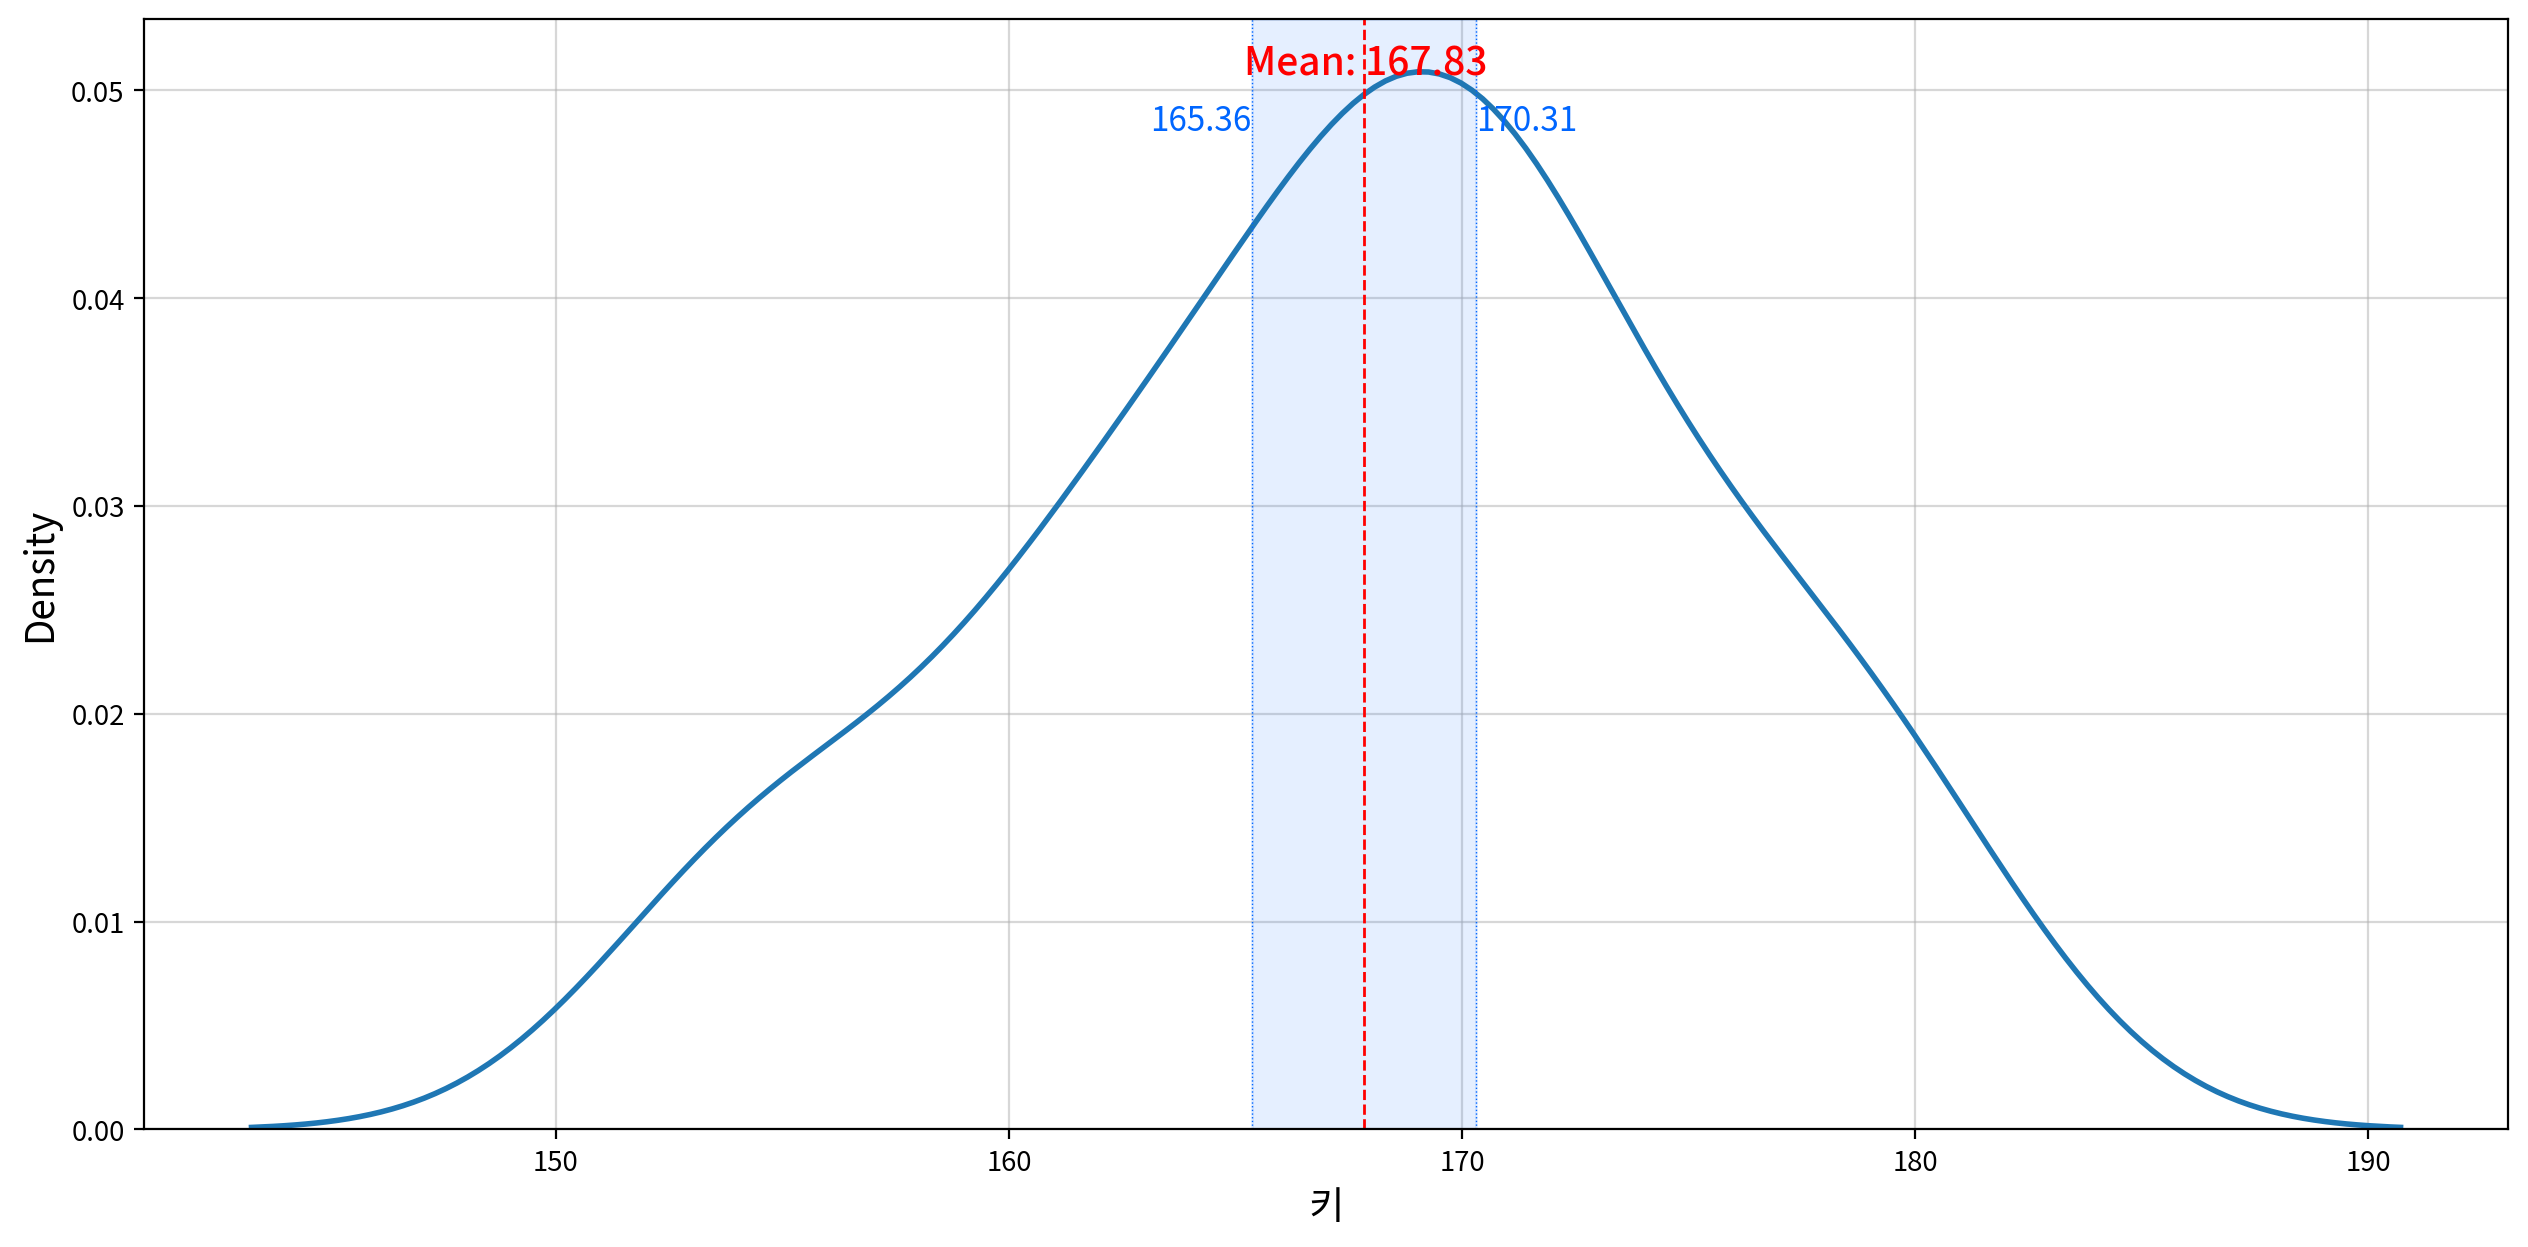

In [14]:
# ax객체를 사용하여 추가적인 그래프 요소를 그릴 수 있도록 직접 초기화
fig, ax = my_plot.init()

# KDE 플롯 그리기(평균선 포함)
my_plot.kdeplot(origin, '키', meanline=True, ax=ax)

# 신뢰구간 계산
cmin, cmax = my_stats.ci(origin, column='키', clevel=0.95)

# 신뢰구간 범위에 대한 세로 직전 그리기 (cmin~cmax)
ax.axvline(cmin, linestyle=':', color="#0066ff", linewidth=0.5)
ax.axvline(cmax, linestyle=':', color="#0066ff", linewidth=0.5)

# 신뢰구간 범위에 대한 텍스트 추가
ax.text(cmin, ax.get_ylim()[1]*0.9, f'{cmin:.2f}', color="#0066ff", ha='right')
ax.text(cmax, ax.get_ylim()[1]*0.9, f'{cmax:.2f}', color="#0066ff", ha='left')

ymin, ymax = ax.get_ylim() # 현재 축 범위 가져오기
ax.set_ylim(ymin, ymax) # y축 범위 설정(0부터 ymax까지)

# 신뢰구간 범위에 대한 영역 채우기(cmin~cmax)
ax.fill_between([cmin, cmax], 0, ymax, alpha=0.1, color="#0066ff")

my_plot.show()

## #05. 시각화 모듈 기능 확인
### 1. 단일 데이터에 대한 신뢰구간 확인

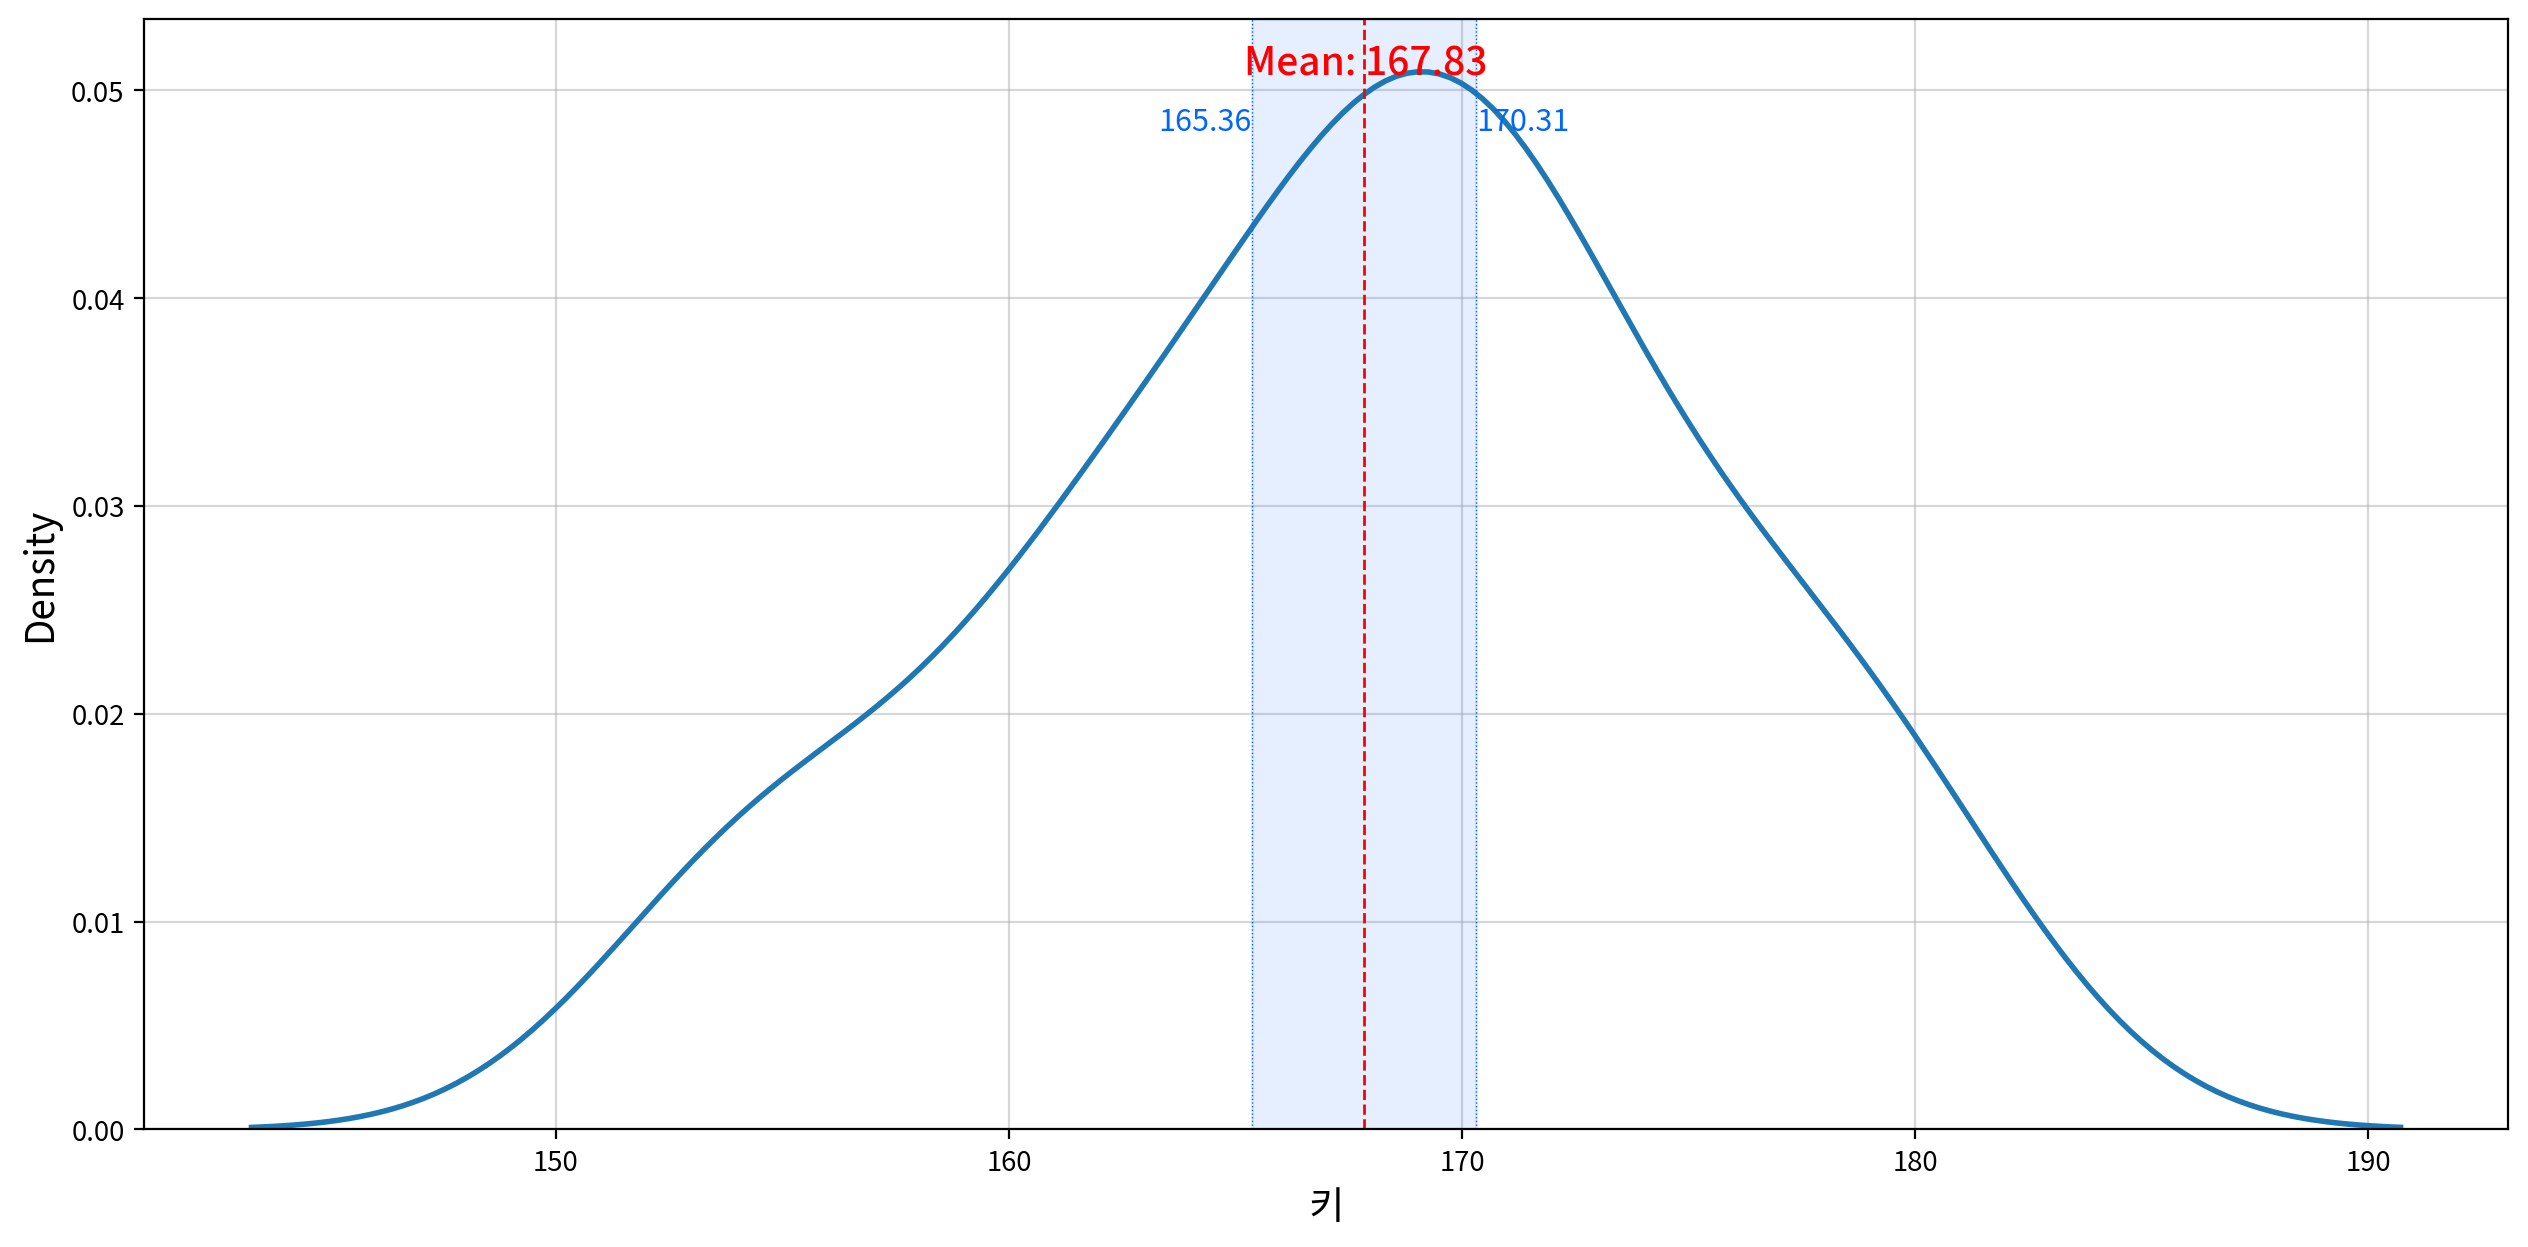

In [15]:
my_plot.kdeplot(origin, '키', meanline=True, clevel=0.95)

### 2. 범주별 신뢰구간 확인

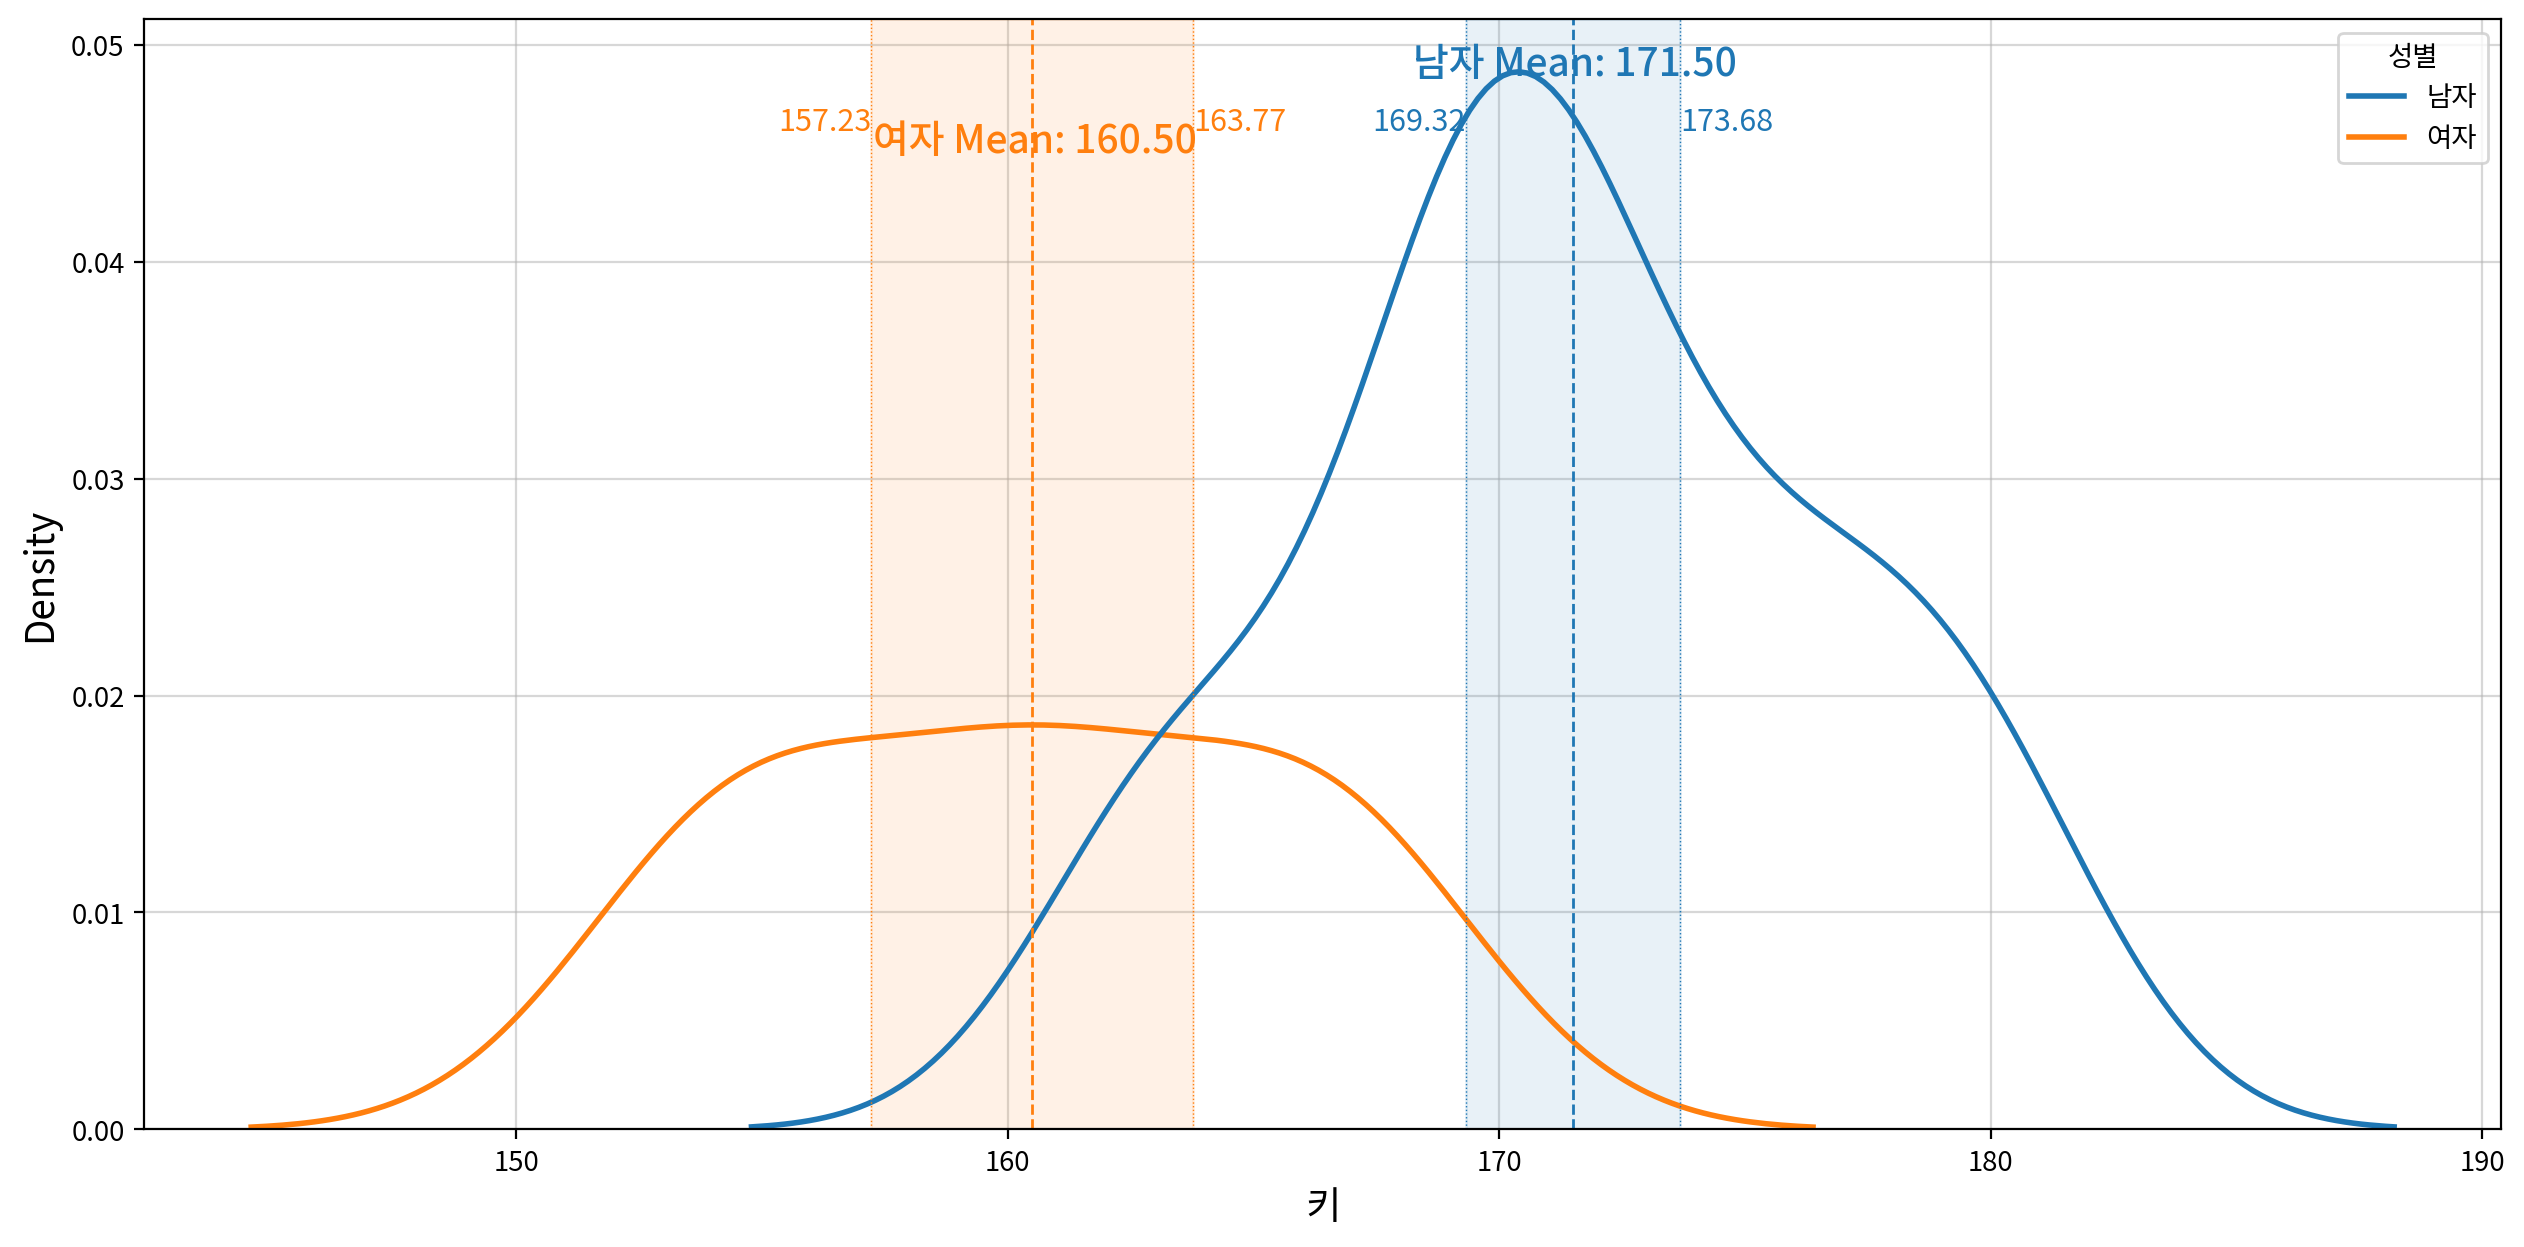

In [16]:
my_plot.kdeplot(origin, '키', hue='성별', meanline=True, clevel=0.95)